# Initializations

## Notes on terminology
- `src_pos` is source position in terms of $R_{orbit}$
- `y` is source position in terms of $\theta_E$
- `beta` is source position in terms of $R_S$

## Module imports

In [105]:
from pathlib import Path
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, BoundaryNorm, ListedColormap

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network

## Function definitions

### `block_map`

#### Definition

In [106]:
def block_map(fun, events: dict, sqrt_nb_blocks: int=10, merge_result: bool=True):
    """Applies the function `fun` throughout `events` by splitting `events` into
    `sqrt_nb_blocks`*`sqrt_nb_blocks` blocks, and applying `fun` to each block
    successively, before recomposing the end matrix result.

    Parameters
    ----------
    fun : function
        function to map onto each individual block
    events : dict
        dictionary of the events, where each parameter is a matrix that will be
        decomposed into blocks
    sqrt_nb_blocks : int
        square root of the number of blocks

    Returns
    -------
    numpy.array
        array of fun applied to each block
    """

    # For now, we assume that nb_block_lines = nb_block_rows = sqrt_nb_blocks
    nb_block_lines = sqrt_nb_blocks
    nb_block_rows = sqrt_nb_blocks

    # Splits the matrix of values
    events_in_blocks = {
        key : [
            np.array_split(v, nb_block_rows, 1)
            for v
            in np.array_split(val, nb_block_lines, 0)
        ]
        for key, val
        in events.items()
    }

    blocks = [
        [
            fun(
                {
                    key : val[i][j]
                    for key, val
                    in events_in_blocks.items()
                }
            )
            for i
            in range(nb_block_lines)
        ]
        for j
        in range(nb_block_rows)
    ]

    if merge_result:
        blocks = np.concatenate([np.concatenate(blk, 0) for blk in blocks], 1)

    return np.array(blocks)

#### Tests and mini-benchmark

The following test should return the original array of `"a"`

In [ ]:
block_map(
    lambda ev: ev["a"],
    dict(
        a=onp.array([[1,2,3],
                     [4,5,6],
                     [7,8,9],
                     [10,11,12]], float),
        b=onp.random.random((3,4))
    ),
    2
)

For $n=100$, we check how much longer using `block_map` makes the computation.

- `HLV_AGN.SNR(events)` finishes in 28.6s
- `block_map(HLV_AGN.SNR, events, 10)` finishes in 55.9s

So, while using `block_map` may help avoid some memory limitations, it also slows down the computation by an approximate factor of 2. Therefore, if we wish to consider $n=1000$, the computation will take $2 \cdot 10^2$ more time than $\approx 30$ secondes, _i.e._ about $\approx 90$ minutes.

### `plot_discrete_colormesh`

In [ ]:
def plot_discrete_colormesh(X, Y, Z, fig, ax, cmap, n_levels=8, lognorm=False, cbar_label=None, labelpad=0, cbar_ticklabels=None):
    vmin, vmax = Z.min(), Z.max()

    if type(n_levels) == int:
        if not lognorm:
            bounds = np.linspace(vmin, vmax, n_levels + 1)
        else:
            bounds = np.geomspace(vmin, vmax, n_levels + 1)
    else:
        bounds = n_levels
        n_levels = len(n_levels)

    colors = cmap(np.linspace(0, 1, n_levels))
    discrete_cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, ncolors=discrete_cmap.N)

    im = ax.pcolormesh(X, Y, Z, cmap=discrete_cmap, norm=norm)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, boundaries=bounds, ticks=bounds)

    # Colorbar tick labels
    if cbar_ticklabels == None:
        cbar_ticklabels = [f'{b:.2e}' for b in bounds]
    cbar.ax.set_yticklabels(cbar_ticklabels)

    # Colorbar label
    if cbar_label is not None:
        cbar.set_label(cbar_label, labelpad=labelpad, loc='top', rotation=0)

    return im

### `Dls_wrt_y_and_R_orbit`

In [ ]:
def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    # y has units of einstein radius, R_orbit has units of R_S
    return (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs

## Injection

In [300]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

# Ryan's original plots

**WARNING**

Currently, the way the $y$ and $R_\text{orbit}$ parameters are articulated with respect to each other is WRONG!

For each $R_\text{orbit}$, the source position in terms of $R_\text{S}$ or $R_\text{orbit}$ needs to be adapted if one keeps $y := \beta / \theta_\text{E}$ constant.

In [ ]:
n = 100
shape = (n, n)
# A benchmark event, at dL = 1Gpc
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24),
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5),
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2),
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4),
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66),
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(10, 1000, n)
# src_pos_array = np.geomspace(0.02, 0.99, n)
src_pos_array = np.geomspace(0.02, 0.58, n) # 0.58 is the largest src_pos such that signal lengths don't exceed max resolvable duration
R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh
events['src_pos'] = src_pos_mesh

## SNR at 1 Gpc

In [ ]:
SNR_at_1_Gpc = HLV_AGN.SNR(events)

Use the following snippet, if you use _e.g._ $n = 1000$. It is, however, much longer to compute (order of 1-2 hours).

In [ ]:
SNR_at_1_Gpc = block_map(HLV_AGN.SNR, events, 10)

### Save/load CSV file

In [ ]:
onp.savetxt("SNR_at_1_Gpc.csv", SNR_at_1_Gpc, delimiter=",")

In [113]:
SNR_at_1_Gpc = onp.genfromtxt("SNR_at_1_Gpc.csv", float, delimiter=",")

### Quick preview

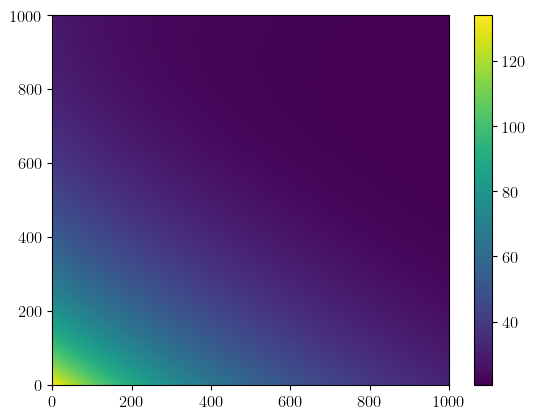

In [114]:
plt.pcolor(SNR_at_1_Gpc)
plt.colorbar()

## Compute $\Delta\iota$, $\Delta\mathcal M/\mathcal M$

In [115]:
general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = general_event_params['relative_mass']
frac_mass_diff = onp.asarray(np.abs(relative_mass - 1))

## Convert into $y\equiv\beta/\theta_E$

In [116]:
# y_max = 1 Einstein radius
Dls_min = Dls_wrt_y_and_R_orbit(1, R_orbit_array) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2*Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S

y_array = src_pos_array * R_orbit_array / beta_max

## Plot

Text(0.5, 0.98, 'Contours = SNR / Gpc ($y$ values truncated at max resolvable signal duration)')

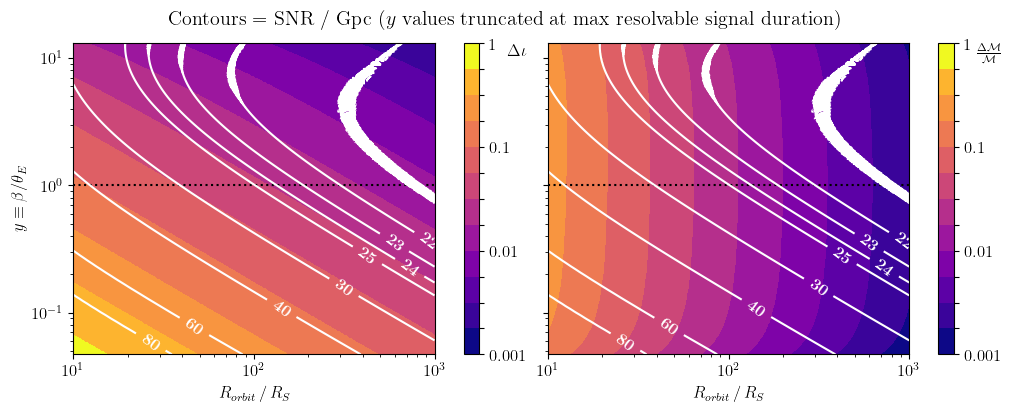

In [117]:
cmap = plt.get_cmap('plasma')

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey='row', constrained_layout=True)

n_levels = np.logspace(-3, 0, 12+1)
cbar_ticklabels = [r"$"+f"{i:.2f}"+r"$" for i in np.linspace(-3, 0, 12+1)]
cbar_ticklabels = ["0.001","","","","0.01","","","","0.1","","","","1"]

ax = axs[0]
plot_discrete_colormesh(
    R_orbit_array,
    y_array,
    delta_iota,
    fig,
    ax,
    cmap,
    n_levels=n_levels,
    lognorm=True,
    cbar_label=r'$\Delta\iota$',
    labelpad=0,
    cbar_ticklabels=cbar_ticklabels
)
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

ax = axs[1]
plot_discrete_colormesh(
    R_orbit_array,
    y_array,
    frac_mass_diff,
    fig,
    ax,
    cmap,
    n_levels=n_levels,
    lognorm=True,
    cbar_label=r'$\frac{\Delta \mathcal M}{\mathcal M}$',
    labelpad=0,
    cbar_ticklabels=cbar_ticklabels
)

# Hard-picked label locations for contour lines
# nice_positions = [
#     [30, 0.1],
#     [40, 0.2],
#     [70, 0.7],
#     [100, 1]
# ]

SNR_levels = [20,21,22,23, 24, 25, 30, 40, 60, 80]
for ax in axs:
    ax.hlines(1, 10**1, 10**3, colors="k", linestyles=":")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')
    contour = ax.contour(
        R_orbit_array,
        y_array,
        SNR_at_1_Gpc,
        levels=SNR_levels,
        colors='white'
    )
    fmt = lambda val: rf'$\mathbf{{{int(val)}}}$'
    ax.clabel(contour, fmt=fmt, colors='white'
            #   , manual=nice_positions
              )

fig.suptitle(r'Contours = $\log_{10}({\rm SNR} / {\rm Gpc})$ ($y$ values truncated at max resolvable signal duration)')
fig.suptitle(r'Contours = SNR / Gpc ($y$ values truncated at max resolvable signal duration)')

# A second look at it

## Event parameters definition

In [ ]:
# Playing around a bit
this_R_orbit = 10
Dls_min = Dls_wrt_y_and_R_orbit(1, this_R_orbit) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2*Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S

beta_max / this_R_orbit

Array(0.42543802, dtype=float64, weak_type=True)

In [306]:
n = 100
shape = (n, n)
# A benchmark event, at dL = 1Gpc
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24),
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5),
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2),
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4),
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66),
}

# y_max = 1 Einstein radius

# Sample parameter space
y_array = np.logspace(-2, 1, n)
R_orbit_array = np.logspace(1, 4, n)

Dls_min = Dls_wrt_y_and_R_orbit(1, R_orbit_array) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2*Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S

events['src_pos'] = np.outer(y_array, beta_max / R_orbit_array)

R_orbit_mesh, _ = np.meshgrid(R_orbit_array, y_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh

events = {key: val.astype(np.float64) for key, val in events.items()}

## SNR at 1 Gpc

In [292]:
SNR_at_1_Gpc = HLV_AGN.SNR(events)
SNR_at_1_Gpc

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: [[        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]
 ...
 [        nan         nan         nan ... 13.38784183 13.38334342
  13.37915424]
 [        nan         nan         nan ... 14.36076557 14.35499161
  14.34961604]
 [        nan         nan         nan ... 15.4791177  15.47165991
  15.46471889]], Maximum duration: [[24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144]
 [24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144]
 [24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144]
 ...
 [24.60698144 24.60698144 24.60698144 ... 24.60698144 24.60698144
  24.60698144

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ..., 20.59072881,
        20.58620779, 20.59269497],
       [        nan,         nan,         nan, ..., 20.59810369,
        20.60509291, 20.58896577],
       [        nan,         nan,         nan, ..., 20.58523869,
        20.59181812, 20.59072375]], shape=(100, 100))

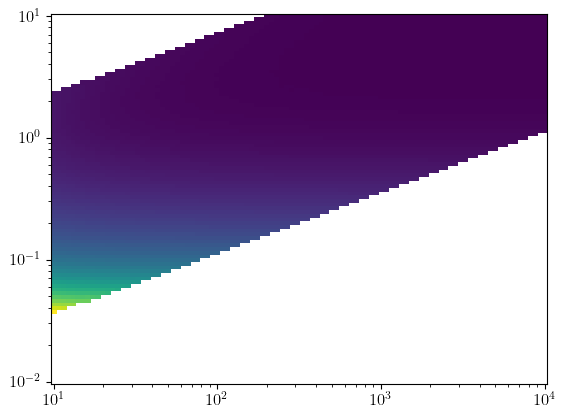

In [293]:
plt.pcolor(R_orbit_array, y_array, SNR_at_1_Gpc)
plt.xscale("log")
plt.yscale("log")

### Save/load CSV file

In [294]:
onp.savetxt("SNR_at_1_Gpc-bis.csv", SNR_at_1_Gpc, delimiter=",")

In [153]:
SNR_at_1_Gpc = onp.genfromtxt("SNR_at_1_Gpc-bis.csv", float, delimiter=",")

## Compute $\Delta\iota$, $\Delta\mathcal M/\mathcal M$

In [295]:
general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = general_event_params['relative_mass']
frac_mass_diff = onp.asarray(np.abs(relative_mass - 1))

## Plot

Text(0.5, 0.98, 'Contours = SNR / Gpc ($y$ values truncated at max resolvable signal duration)')

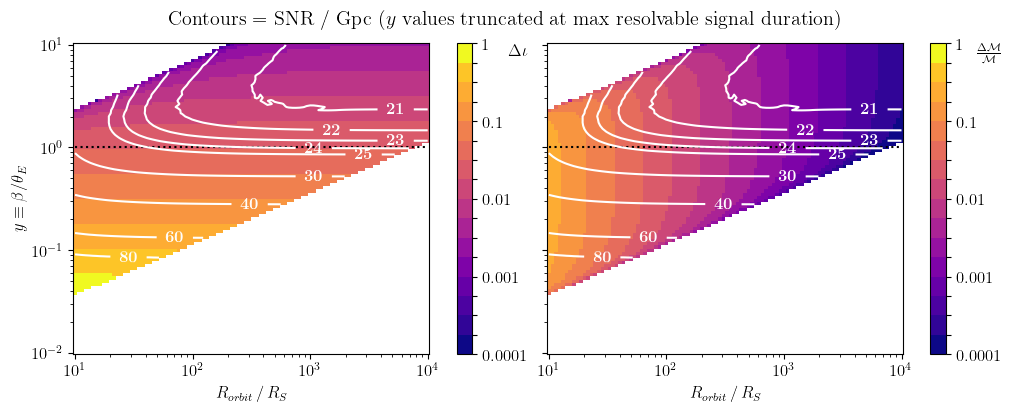

In [296]:
cmap = plt.get_cmap('plasma')

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey='row', constrained_layout=True)

n_levels = np.logspace(-4, 0, 16+1)
cbar_ticklabels = [r"$"+f"{i:.2f}"+r"$" for i in np.linspace(-4, 0, 16+1)]
cbar_ticklabels = ["0.0001","","","","0.001","","","","0.01","","","","0.1","","","","1"]

ax = axs[0]
plot_discrete_colormesh(
    R_orbit_array,
    y_array,
    delta_iota,
    fig,
    ax,
    cmap,
    n_levels=n_levels,
    lognorm=True,
    cbar_label=r'$\Delta\iota$',
    labelpad=0,
    cbar_ticklabels=cbar_ticklabels
)
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

ax = axs[1]
plot_discrete_colormesh(
    R_orbit_array,
    y_array,
    frac_mass_diff,
    fig,
    ax,
    cmap,
    n_levels=n_levels,
    lognorm=True,
    cbar_label=r'$\frac{\Delta \mathcal M}{\mathcal M}$',
    labelpad=0,
    cbar_ticklabels=cbar_ticklabels
)

# Hard-picked label locations for contour lines
# nice_positions = [
#     [30, 0.1],
#     [40, 0.2],
#     [70, 0.7],
#     [100, 1]
# ]

SNR_levels = [20,21,22,23, 24, 25, 30, 40, 60, 80]
for ax in axs:
    ax.hlines(1, 10**1, 10**4, colors="k", linestyles=":")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')
    contour = ax.contour(
        R_orbit_array,
        y_array,
        SNR_at_1_Gpc,
        levels=SNR_levels,
        colors='white'
    )
    fmt = lambda val: rf'$\mathbf{{{int(val)}}}$'
    ax.clabel(contour, fmt=fmt, colors='white'
            #   , manual=nice_positions
              )

fig.suptitle(r'Contours = $\log_{10}({\rm SNR} / {\rm Gpc})$ ($y$ values truncated at max resolvable signal duration)')
fig.suptitle(r'Contours = SNR / Gpc ($y$ values truncated at max resolvable signal duration)')

# Others...

In [156]:
# Below is the code for continuous colorbar

# SNR_levels = [25, 30, 40, 60]

# fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey='row', constrained_layout=True)

# ax = axs[0]
# im = ax.pcolormesh(R_orbit_array, y_array, delta_iota,
#                        norm=LogNorm()
#                        )
# cbar = fig.colorbar(im)
# cbar.set_label(r'$\Delta\iota$', labelpad=-10, loc='top', rotation=0)
# contour = ax.contour(R_orbit_array, y_array, SNR_at_1_Gpc,
#                          levels=SNR_levels, colors='black')
# ax.clabel(contour, fmt='%1.1f', colors='black')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylabel(r'$y\equiv\beta/\theta_E$')
# ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')

# ax = axs[1]
# im = ax.pcolormesh(R_orbit_array, y_array, frac_mass_diff,
#                        norm=LogNorm()
#                        )
# cbar = fig.colorbar(im)
# cbar.set_label(r'$\Delta\mathcal{M}\,/\,\mathcal{M}$', labelpad=40, loc='top', rotation=0)
# contour = ax.contour(R_orbit_array, y_array, SNR_at_1_Gpc,
#                          levels=SNR_levels, colors='black')
# ax.clabel(contour, fmt='%1.1f', colors='black')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')

# fig.suptitle(r'Contours = SNR / Gpc')

# EoF